# **1. Generación de Ingredientes con GPT**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhonattanreales21/nlp_icesi/blob/main/unidad_5/Cano_Reales_text_generation_gpt.ipynb)

El objetivo de este proyecto es desarrollar un modelo de generación de texto basado en arquitecturas tipo GPT (Generative Pre-trained Transformer), con el fin de producir **listas de ingredientes coherentes y plausibles** a partir de una **categoría o receta culinaria**.

En este enfoque se plantea una tarea más específica y controlada: **aprender la relación entre el tipo de receta y los ingredientes que normalmente la componen**.

Lo anterior responde a dos razones principales:

**a**. **Simplificación de la tarea generativa**  
   En vez de usar el dataset para generar recetas completas, lo cual implica modelar secuencias largas, con varios componentes narrativos y procedimentales (nombre, ingredientes, pasos, e incluso metadatos adicionales); se generan únicamente ingredientes, lo que permite reducir la complejidad del problema y concentrar el aprendizaje en un patrón semántico más acotado.

**b.** **Mayor viabilidad computacional**  
   Al trabajar con secuencias más cortas, el costo de tokenización y entrenamiento disminuye considerablemente. Esto abre la posibilidad de entrenar el modelo con una porción mucho mayor del dataset, e incluso potencialmente con la totalidad de los ejemplos disponibles, manteniendo la viabilidad en Google Colab con GPU T4.

En este sentido, el proyecto busca evaluar si un modelo GPT en español puede aprender asociaciones útiles entre categorías culinarias e ingredientes frecuentes, por ejemplo:

- postres → azúcar, harina, leche, canela
- sopas → agua, cebolla, ajo, zanahoria

---

## **Descripción del dataset**

Para este proyecto se utiliza el dataset **"RecetasDeLaAbuela" (SomosNLP)**.

Este dataset corresponde a un corpus estructurado de recetas de cocina en español, construido a partir de técnicas de *web scraping* sobre múltiples fuentes gastronómicas.

### **Características principales**

- Más de 20 mil recetas
- Aproximadamente 6 millones de palabras
- Más de 40 millones de caracteres
- Dataset tabular con 14 atributos por receta

### **Estructura del dataset**

Cada receta contiene los siguientes atributos:

- **Id**: Identificador único
- **Nombre**: Nombre de la receta
- **URL**: Fuente de origen
- **Ingredientes**: Lista de ingredientes
- **Pasos**: Instrucciones de preparación
- **Pais**: Origen geográfico
- **Duracion**: Tiempo estimado de preparación
- **Categoria**: Tipo de receta (postres, carnes, vegetarianos, etc.)
- **Contexto**: Entorno de consumo
- **Valoracion y Votos**
- **Comensales**
- **Tiempo**
- **Dificultad**
- **Valor nutricional**

---

## **Justificación**

Aunque el dataset contiene suficiente información para generar recetas completas, en esta versión del proyecto se decide trabajar únicamente con los campos:

- **Categoria**
- **Ingredientes**
- **Nombre** (Ante valores NA)

La razón de esta decisión es que estos atributos contienen el núcleo de la relación semántica que se quiere modelar: **qué ingredientes suelen asociarse a cada tipo de receta**.

En cambio, otros campos como `Pasos` o `Pais`, aunque útiles en un escenario de generación más amplio, incrementan la longitud de las secuencias y la complejidad del aprendizaje, lo que dificulta el entrenamiento completo del modelo bajo restricciones computacionales.

Así, este diseño permite:

- reducir la longitud promedio de las secuencias,
- aprovechar una mayor proporción del dataset,
- mejorar la estabilidad del entrenamiento,
- y enfocar el aprendizaje en una tarea más concreta y medible.

---

## **Metodología**

El proyecto seguirá las siguientes etapas:

### **a. Exploratory Data Analysis (EDA)**
Se realizará un análisis exploratorio del dataset completo para comprender:

- la estructura general del corpus,
- la calidad de los campos disponibles,
- la presencia de valores faltantes,
- la distribución de categorías,
- y la longitud de los textos.

### **b. Limpieza y selección de variables**
A partir del análisis estructural, se seleccionarán los campos antes mencionados, serán sometidos a un proceso de limpieza para obtener el formato deseado, y por ultimo, serán transformados en un texto unificado que sirva de entrada para el modelo.

### **c. Construcción del texto objetivo**
Cada ejemplo será representado con una estructura simple y consistente, por ejemplo:

```text
### Categoría:
postres

### Ingredientes:
azúcar, harina, leche, mantequilla, canela

```

## **Selección del modelo base**

Para este proyecto se seleccionó el modelo **`mrm8488/spanish-gpt2`**, una variante de GPT-2 preentrenada en español.

La elección de este modelo responde a un proceso iterativo que combinó criterios teóricos y evidencia empírica.

Inicialmente, se exploró el uso de modelos alternativos como `DeepESP/gpt2-spanish`, con el objetivo de evaluar distintas opciones disponibles en el ecosistema de Hugging Face. Sin embargo, durante las pruebas iniciales se identificaron problemas de estabilidad, incluyendo advertencias en la carga de pesos y comportamientos inconsistentes durante el entrenamiento (valores extremos y `NaN` en la función de pérdida).

En consecuencia, se selecciona `mrm8488/spanish-gpt2` como modelo base para el proceso de fine-tuning, priorizando estabilidad, reproducibilidad y adecuación al problema planteado.




#### Referencias
- Dataset: [RecetasDeLaAbuela (SomosNLP)](https://huggingface.co/datasets/somosnlp/RecetasDeLaAbuela?utm_source=chatgpt.com)  
- [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)  
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)  
- [GPT2-base-bne (Modelo en español - PlanTL)](https://huggingface.co/PlanTL-GOB-ES/gpt2-base-bne)  
- [Fine-Tune a non-English GPT-2 Model with Hugging Face](https://www.philschmid.de/fine-tune-a-non-english-gpt-2-model-with-huggingface)  
- [SomosNLP - Comunidad de NLP en español](https://huggingface.co/somosnlp)  

In [84]:
!pip -q install transformers datasets evaluate accelerate sentencepiece wordcloud

In [85]:
import os
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

warnings.filterwarnings("ignore")

In [86]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [87]:
# Carga del modelo base y tokenizer

model_ckpt = "mrm8488/spanish-gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForCausalLM.from_pretrained(model_ckpt).to(device)

# GPT-2 no suele incluir pad_token por defecto
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id

print("Modelo cargado:", model_ckpt)
print("Dispositivo:", device)
print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)
print("Tamaño del vocabulario:", tokenizer.vocab_size)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado: mrm8488/spanish-gpt2
Dispositivo: cuda
Pad token: <|endoftext|>
EOS token: <|endoftext|>
Tamaño del vocabulario: 50265


# **2. Carga e Inspección del Dataset**

Una vez seleccionado el modelo base, el siguiente paso consiste en cargar e inspeccionar el dataset **RecetasDeLaAbuela**.

Esta etapa es fundamental porque permite:

- verificar el tamaño real del corpus,
- identificar las columnas disponibles,
- revisar el formato de cada atributo,
- detectar posibles valores faltantes,
- y entender cómo debe construirse el texto final que será usado para el fine-tuning.

Dado que el objetivo del proyecto es generar recetas completas y coherentes, resulta especialmente importante inspeccionar cómo vienen representados los campos más relevantes, como el **nombre de la receta**, los **ingredientes** y los **pasos de preparación**.

In [88]:
# Carga del dataset

from datasets import load_dataset

dataset = load_dataset("somosnlp/RecetasDeLaAbuela", "version_1")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['Id', 'Nombre', 'URL', 'Ingredientes', 'Pasos', 'Pais', 'Duracion', 'Categoria', 'Contexto', 'Valoracion y Votos', 'Comensales', 'Tiempo', 'Dificultad', 'Valor nutricional'],
        num_rows: 20236
    })
})


In [89]:
# Inspección inicial de la estructura

print("Splits disponibles:", list(dataset.keys()))
print("\nColumnas del dataset:")
print(dataset["train"].column_names)

print("\nPrimer registro:")
print(dataset["train"][0])

Splits disponibles: ['train']

Columnas del dataset:
['Id', 'Nombre', 'URL', 'Ingredientes', 'Pasos', 'Pais', 'Duracion', 'Categoria', 'Contexto', 'Valoracion y Votos', 'Comensales', 'Tiempo', 'Dificultad', 'Valor nutricional']

Primer registro:
{'Id': 1, 'Nombre': 'Tacos Dorados de Papa', 'URL': 'https://www.mexicoenmicocina.com/tacos-dorados-de-papa/', 'Ingredientes': '½ taza de cilantro finamente picado, 1 taza de tomate picadito y sin semillas, 1 cucharada de jugo de limón, 12 to rtillas de maíz, ⅔ de taza de aceite vegetal para freír los taquitos, 2 chiles serranos en cubitos, Sal al gusto, 2 tazas de repollo en tiras finas, ½ taza de crema mexicana, Salsa roja, ½ taza de cebolla blanca en cubitos, 3 papas rojas de tamaño mediano ~510 gr. *, 24 palillos de madera para sostener los taquitos enrollados, 1 aguacate opcional, Sal y pimienta al gusto, ½ taza de Queso Cotija o Queso Fresco desmenuzado**', 'Pasos': 'Pon las papas enteras en una olla mediana y cúbrelas con agua fría. NO p

In [90]:
# Tamaño del dataset

print("Número de registros en train:", len(dataset["train"]))

Número de registros en train: 20236


In [91]:
# Vista tabular de algunos ejemplos

sample_df = pd.DataFrame(dataset["train"][:5])
sample_df.head()

,Id,Nombre,URL,Ingredientes,Pasos,Pais,Duracion,Categoria,Contexto,Valoracion y Votos,Comensales,Tiempo,Dificultad,Valor nutricional
0,1,Tacos Dorados de Papa,https://www.mexicoenmicocina.com/tacos-dorados...,"½ taza de cilantro finamente picado, 1 taza de...",Pon las papas enteras en una olla mediana y cú...,MEX,01:00,vegetarianos,None,None,6,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"
1,2,Ensalada de Chayotes,https://www.mexicoenmicocina.com/receta-ensala...,"½ cucharadita sal, ¼ cucharadita de pimienta r...",Coloca los chayotes en una cacerola y cúbralos...,MEX,00:25,vegetarianos,None,None,4,None,None,"Bajo en calorías, Sin grasa, Alto en fibra"
2,3,Huevos a la Mexicana,https://www.mexicoenmicocina.com/huevos-a-la-m...,"½ Chile Serrano cortado en pequeños trocitos*,...",Calienta el aceite en una sartén mediana a fue...,MEX,00:15,vegetarianos,None,None,1,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"
3,4,Rajas de Chile Poblano con Crema,https://www.mexicoenmicocina.com/rajas-de-chil...,"½ cucharadita Sal, 2 cucharadas de aceite vege...",Para asar los chiles:Colocas los chiles ya lim...,MEX,00:30,vegetarianos,None,None,None,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"
4,5,Papas a la Mexicana,https://www.mexicoenmicocina.com/papas-a-la-me...,"⅓ taza de cebolla blanca en cubitos, Sal al gu...",Calienta el aceite vegetal en una sartén grand...,MEX,00:25,vegetarianos,None,None,None,None,None,"Alto en calorías, Alto en grasas, Alto en sodio"


# **3. Análisis estructural del dataset y estrategia de formateo**

## **Selección de variables**

A partir del análisis exploratorio del dataset, se identificaron múltiples atributos disponibles por receta, incluyendo nombre, ingredientes, pasos, país, categoría y otros metadatos.

Sin embargo, para el enfoque actual del proyecto, se decidió trabajar únicamente con los siguientes campos:

- **Categoria**
- **Ingredientes**
- **Nombre**

## **Justificación**

En lugar de generar recetas completas, se busca modelar la relación entre el tipo de receta y los ingredientes que la componen.

En particular:

- **Categoria** actúa como una variable de contexto que condiciona la generación. **Nombre** ofrece una alternativa semanticamente similar pero siendo mas explicita.
- **Ingredientes** representa el contenido objetivo que el modelo debe aprender a generar.

Dado que el objetivo es entrenar el modelo con una mayor proporción del dataset (idealmente completo), se prioriza una representación más compacta del texto. Lo anterior se alcanzará mediante procesos de limpieza y expresiones regulares.

El modelo será entrenado para aprender una función del tipo: Categoria/Receta -> Ingredientes, lo cual constituye una tarea de generación condicionada más simple, interpretable y eficiente computacionalmente.


## **3.1 Revisar nulos y calidad de columnas**

In [92]:
# Revisión de valores faltantes


df_raw = pd.DataFrame(dataset["train"])

missing_counts = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame(
    {"missing_count": missing_counts, "missing_pct": missing_pct.round(2)}
)

missing_df

,missing_count,missing_pct
Tiempo,9678,47.83
Contexto,8723,43.11
Valoracion y Votos,6915,34.17
Categoria,6748,33.35
Duracion,6630,32.76
Comensales,6627,32.75
Dificultad,6454,31.89
Pais,5591,27.63
Pasos,0,0.00
Nombre,0,0.00


El análisis de valores faltantes muestra que los campos principales del contenido narrativo de las recetas (`Nombre`, `Ingredientes`, `Pasos`) no presentan valores nulos, lo cual garantiza una base sólida para el entrenamiento del modelo.

Sin embargo, variables adicionales como `Categoría` y `País` presentan niveles moderados de datos faltantes (27%–33%), mientras que otras variables superan el 40% de ausencia.

Dado este comportamiento, es necesario tomar una decisión sobre las observaciones con el campo `Categoría` faltante.

## **3.2 Longitud básica de campos principales**

In [93]:
#  Longitud de los campos principales

df_raw["len_nombre_chars"] = df_raw["Nombre"].fillna("").apply(len)
df_raw["len_ingredientes_chars"] = df_raw["Ingredientes"].fillna("").apply(len)
df_raw["len_categoria_chars"] = df_raw["Categoria"].fillna("").apply(len)
df_raw["len_pasos_chars"] = df_raw["Pasos"].fillna("").apply(len)


df_raw[
    [
        "len_nombre_chars",
        "len_ingredientes_chars",
        "len_categoria_chars",
        "len_pasos_chars",
    ]
].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,len_nombre_chars,len_ingredientes_chars,len_categoria_chars,len_pasos_chars
count,20236.000000,20236.000000,20236.000000,20236.000000
mean,25.491550,250.859705,17.113609,1169.780737
std,8.630606,123.129856,28.142556,683.839363
min,3.000000,2.000000,0.000000,40.000000
50%,25.000000,232.000000,2.000000,1075.000000
75%,31.000000,313.000000,21.000000,1551.000000
90%,37.000000,408.000000,53.000000,2041.000000
95%,40.000000,479.000000,78.000000,2393.000000
99%,49.000000,641.300000,126.000000,3171.300000
max,78.000000,1261.000000,216.000000,10611.000000


El análisis de longitud revela que el campo `Pasos` concentra la mayor cantidad de información textual, con una mediana superior a 1000 caracteres y una cola larga que alcanza valores extremos.

Por su parte, el campo `Ingredientes` presenta secuencias considerablemente más cortas que `Pasos`; sin embargo, existen casos extremos que superan los 400 caracteres, lo que hace necesario aplicar **clipping** (truncamiento) y/o aplicar un paso de limpieza de caracteres no utiles para el caso de uso, con el objetivo de garantizar que las secuencias se ajusten a la longitud máxima admitida por el modelo.

Finalmente, `Categoria` es la variable con las secuencias más cortas del dataset, al tratarse de etiquetas de texto breve que identifican el tipo de receta. Tambien notamos que guarda cierta similitud con el numero de caracteres de la variable `Nombre`.

## **3.3 Niveles y ejemplos de variables**

In [94]:
# Revisar el numero de niveles distintos por las columnas nombre, ingredientes y categoria.
for col in ["Nombre", "Ingredientes", "Categoria"]:
    print(f"Columna: {col}")
    print(f"Niveles distintos: {df_raw[col].nunique()}")
    print(
        f"Sample de 5 valores al azar:\n{df_raw[col].sample(5, random_state=1).values}\n"
    )

Columna: Nombre
Niveles distintos: 20014
Sample de 5 valores al azar:
['turron de jijona blando con thermomix' 'cazuela de bagre con camarones'
 'crema de zanahoria y naranja saludable' 'lenguado frito con pinones'
 'budin de miel']

Columna: Ingredientes
Niveles distintos: 20174
Sample de 5 valores al azar:
["['130 gramos de Azúcar', '300 gramos de Almendra tostada', '50 gramos de Chocolate para fundir', '30 gramos de Miel']"
 "['1 kilogramo de Bagre en rebanadas', '1 kilogramo de Camarones', '1 cubo de Caldo de gallina', '4 dientes de Ajo machacado', '1 unidad de Cebolla cabezona mediana rayada', '4 tazas de Agua                                                                    (960 mililitros)', '2 cucharadas soperas de Harina de trigo (normal que no tenga levadura)', '1½ litros de Leche', '4 cucharadas soperas de Mantequilla', '1 taza de Pan tostado rayado']"
 "['4 zanahorias', '1 cebolla blanca', 'Medio vaso de jugo de naranja', '4 cucharadas de crema de leche', 'Sal', 'Pimienta'

Al analizar los niveles y ejemplos de las tres variables anteriores, observamos que:
- **`Nombre` e `Ingredientes` tienen alta diversidad**, lo cual es esperable en un corpus de recetas y aporta riqueza léxica para el entrenamiento.
- En **`Categoria` hay potenciales problemas de calidad semántica y de formato**.

**Implicación para el modelado**
Antes de entrenar, es necesario estandarizar `Categoria` para que represente etiquetas comparables y útiles. En particular:

1. tratar nulos/`Desconocido`,
2. normalizar categorías mal formateadas (listas como texto),
3. unificar variantes semánticamente equivalentes.

Con esta limpieza, la relación **Categoría → Ingredientes** será más consistente y el fine-tuning tendrá una señal supervisada de mejor calidad.

## **3.4 Distribución de categorías**

Categoria
N/A                                                              6748
[]                                                               5614
['Recetas al horno']                                             1230
['Recetas mexicanas']                                             584
['Recomendada para perder peso']                                  324
['Recetas españolas']                                             309
['Recomendada para vegetarianos']                                 297
['Recomendada para veganos']                                      235
['Recomendada para veganos', 'Recomendada para vegetarianos']     226
['Recetas para Navidad']                                          180
['Recomendada para vegetarianos', 'Recetas al horno']             166
['Recetas peruanas']                                              111
['Recetas italianas']                                             103
['Recetas colombianas']                                            84
['Recetas 

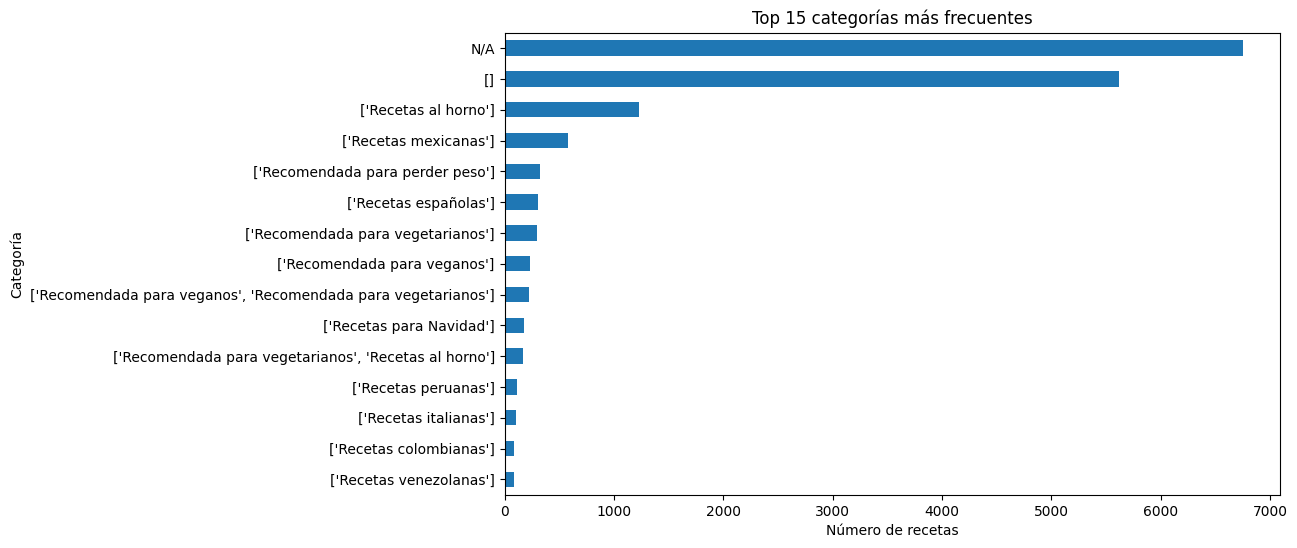

In [95]:
# Categorías más frecuentes

top_categorias = df_raw["Categoria"].fillna("N/A").value_counts().head(15)
print(top_categorias)

plt.figure(figsize=(10, 6))
top_categorias.sort_values().plot(kind="barh")
plt.title("Top 15 categorías más frecuentes")
plt.xlabel("Número de recetas")
plt.ylabel("Categoría")
plt.show()

**Notas**

Tenemos un hallazgo **CRÍTICO**, la presencia de muchas observaciones con columna `Categoria` NULA.  Teniendo en cuenta que esta es una de nuestras dos variables mas importantes para construcción del corpus, esto representa un caso muy importante a tomar enconsideración. Tambien notamos niveles con categorias mal formateadas ([], listas como texto).

Es de vital importancia limpiar o tomar decisiones en las observaciones que presenten estos casos.


## 3.5 Analisis de observaciones sin Categoria

In [96]:
## Identificar el porcentaje de observaciones con categorias en nulo ([]) o "Desconocido"
categoria = df_raw["Categoria"].astype("string").str.strip()

mask_nan = df_raw["Categoria"].isna()
mask_empty_list = categoria.eq("[]")

#
n_problem = (mask_nan | mask_empty_list).sum()
pct_problem = 100 * n_problem / len(df_raw)

print(f"Total observaciones: {len(df_raw)}")
print(f"Observaciones problemáticas (NaN, '[]' o 'Desconocido'): {n_problem}")
print(f"Porcentaje: {pct_problem:.2f}%")

pd.DataFrame(
    {
        "count": [
            mask_nan.sum(),
            mask_empty_list.sum(),
            n_problem,
        ],
        "pct": [
            100 * mask_nan.sum() / len(df_raw),
            100 * mask_empty_list.sum() / len(df_raw),
            pct_problem,
        ],
    },
    index=["NaN", "'[]'", "Total problemáticas"],
)

Total observaciones: 20236
Observaciones problemáticas (NaN, '[]' o 'Desconocido'): 12362
Porcentaje: 61.09%


,count,pct
NaN,6748,33.346511
'[]',5614,27.742637
Total problemáticas,12362,61.089148


**Notas:**

Reiteramos que estamos ante un problema crítico de calidad en `Categoria`: **12,362 de 20,236 registros (61.09%)** tienen valores no útiles (`NaN` o `[]`).  
Esto implica que más de la mitad del corpus no aporta una señal clara para la relación **Categoría → Ingredientes**.

## DECISIÓN SOBRE VARIABLE "`CATEGORIA`"

Dado que **61.09% de las observaciones presentan valores no útiles en la columna `Categoria`** (NaN o `[]`), se tomó la decisión de utilizar la columna **`Nombre`** como variable de contexto alternativa en los casos donde `Categoria` sea desconocida o vacía.

**Justificación**

Esta decisión se fundamenta en dos aspectos principales:

- **Coherencia semántica**
El nombre de una receta proporciona información inherentemente relacionada con los ingredientes que la componen. Por ejemplo:
- "Tacos Dorados de Papa" → ingredientes: papa, aceite, cebolla, etc.
- "Crema de Zanahoria" → ingredientes: zanahoria, caldo, leche, etc.

Aunque `Nombre` es menos estructurado que `Categoria`, contiene **señal semántica valiosa** para entrenar la relación ingredientes-contexto.

- **Maximización del dataset de entrenamiento**
Al utilizar `Nombre` como alternativa, evitamos descartar 12,362 registros (61%), lo que permite:
- Aumentar la cantidad de ejemplos disponibles para el fine-tuning
- Mejorar la generalización del modelo
- Mantener la diversidad y riqueza del corpus

- **Robustez ante variabilidad**
El modelo aprenderá a generar ingredientes condicionado tanto a categorías explícitas como a nombres de recetas, lo que lo hace más flexible y capaz de manejar múltiples formas de contexto culinario.

**En conclusión:** esta estrategia transforma un problema de calidad de datos en una oportunidad para enriquecer el aprendizaje del modelo, sin comprometer la coherencia de la tarea.

## **3.6 Limpieza de variables y construcción del texto unificado**

Una vez seleccionadas las variables relevantes (`Categoria` e `Ingredientes`), se construye una representación textual uniforme para cada receta.

Antes de construir el texto final, **cada campo pasa por las siguientes transformaciones**:

- Tratamiento de valores nulos y vacíos
- Normalización de caracteres problemáticos
- Eliminación de cantidades y fracciones
- Eliminación de términos de porción
- Normalización de espacios

El objetivo es que el modelo aprenda patrones de asociación entre la categoría culinaria y los ingredientes típicos que la componen, sin entrar en especificaciones de cantidades ni pasos para la preparación del plato.

Cada ejemplo se transforma en el siguiente formato:

- Categoría: postres
- Ingredientes: azúcar, harina, leche, mantequilla, canela


Este formato permite:

- mantener consistencia en la estructura del input,
- facilitar el aprendizaje de relaciones semánticas,
- y permitir generación condicionada a partir de la categoría.


In [97]:
import re


# Construcción del texto final (categoría → ingredientes)
def clean_text(x):
    # Tratar valores nulos o vacíos como "Desconocido"
    if pd.isna(x) or str(x).strip() in ["", "[]"]:
        return "Desconocido"

    x = str(x).replace("\xa0", " ")

    # Quitar artefactos de listas serializadas, pero conservar separadores útiles
    x = x.replace("[", " ").replace("]", " ").replace("'", " ").replace('"', " ")

    # Eliminar términos de porciones/proporciones
    x = re.sub(
        r"\b(porci[oó]n(?:es)?|raci[oó]n(?:es)?|proporci[oó]n(?:es)?)\b",
        " ",
        x,
        flags=re.IGNORECASE,
    )

    # Eliminar palabras de medidas
    x = re.sub(
        r"\b(cucharad[ao]s?|cucharadita[s]?|pizca?|tazas?|gramo[s]?|gramos?|g?|grs?|gr?|kilogramos?|kg?|litros?|mililitros?)\b",
        " ",
        x,
        flags=re.IGNORECASE,
    )
    x = re.sub(
        r"\b(diente[s]?|rebanada[s]?|vaso[s]?|unidad?|unidades?|sopera[s]?|chorro?|chorrito?|centímetro[s]?|cm?|cúbicos?|unidad[es]|puñado[s]?)\b",
        " ",
        x,
        flags=re.IGNORECASE,
    )

    # Eliminar números escritos en palabras y la palabra "de"
    x = re.sub(
        r"\b(un[ao]|dos|tres|cuatro|cinco|seis|siete|ocho|nueve|diez|de)\b",
        " ",
        x,
        flags=re.IGNORECASE,
    )

    # Eliminar fracciones, números y cantidades
    x = re.sub(r"\b\d+\s*/\s*\d+\b", " ", x)  # 1/2, 3/4
    x = re.sub(r"\b\d+[.,]?\d*\b", " ", x)  # 1, 2.5, 0,25
    x = re.sub(r"[¼½¾⅐-⅟]", " ", x)  # fracciones unicode

    # Mantener letras, espacios, comas y puntos
    x = re.sub(r"[^\w\s,\.]", " ", x)

    # Normalizar espacios
    x = re.sub(r"\s+", " ", x).strip()

    # Normalizar formato de comas y puntos
    x = re.sub(r"\s*,\s*", ", ", x)
    x = re.sub(r"\s*\.\s*", ". ", x)
    x = re.sub(r"\s+", " ", x).strip(" ,.")

    return x if x else "Desconocido"

In [98]:
# Definir función para construir el texto final con formato específico
# Nota: Si la variable Categoria tiene valores nulos, se reemplazará por la variable Nombre.


def build_ingredient_text(example):
    categoria = clean_text(example["Categoria"])
    ingredientes = clean_text(example["Ingredientes"])
    nombre = clean_text(example["Nombre"])

    # Reemplazar categoría nula por nombre
    if categoria == "Desconocido":
        categoria = nombre

    text = f"""### Categoría:
{categoria}

### Ingredientes:
{ingredientes}"""

    return {"text": text}


# Aplicar la función al dataset para crear una nueva columna 'text' con el formato deseado
formatted_dataset = dataset.map(build_ingredient_text)

## **3.7 Verificar el texto generado**

In [99]:
# Imprimimos 3 ejemplos aleatorios
sample = pd.DataFrame(formatted_dataset["train"]).sample(3, random_state=16)["text"]
for i, text in enumerate(sample.values):
    print(f"Ejemplo {i+1}:\n{text}\n{'-'*40}\n")

Ejemplo 1:
### Categoría:
albondigas con vino blanco

### Ingredientes:
ajo, rama perejil, carne picada mezcla carne ternera y cerdo, huevos L, pan rallado, sal, harina para rebozar, aceite oliva para freír, cebollas medinas, ajo, aceite oliva, harina, vino blanco, caldo pollo o carne, hoja laurel, pimienta negra recién molida
----------------------------------------

Ejemplo 2:
### Categoría:
pimientos caramelizados con queso

### Ingredientes:
Pimiento rojo, Vinagre blanco, Azúcar, Agua, Queso crema, Galletas saladas
----------------------------------------

Ejemplo 3:
### Categoría:
Recetas mexicanas

### Ingredientes:
Tortillas maíz, piezas Pechugas pollo desmenuzadas o deshebradas, Aguacate pelado y sin hueso ya machucado con un tenedor, hatsa ablandarlo y quede como cremita, Tomatito rojo o verde mediano en cuadritos, lata Crema agria al gusto, tarro Chiles en vinagres o dorados en aceite, Aceite el necesario
----------------------------------------



# **4. EDA para modelado**

En esta etapa se profundiza en el análisis del corpus con el objetivo de tomar decisiones clave para el entrenamiento del modelo.

En particular, se busca:

- determinar la longitud adecuada de secuencia (`max_length`)
- entender la distribución de tokens
- identificar patrones léxicos relevantes
- evaluar la complejidad del lenguaje culinario

Estas decisiones son fundamentales para garantizar que el modelo pueda aprender eficientemente sin exceder las limitaciones computacionales del entorno (GPU T4).

## **4.1 Histograma - Longitud tokens**

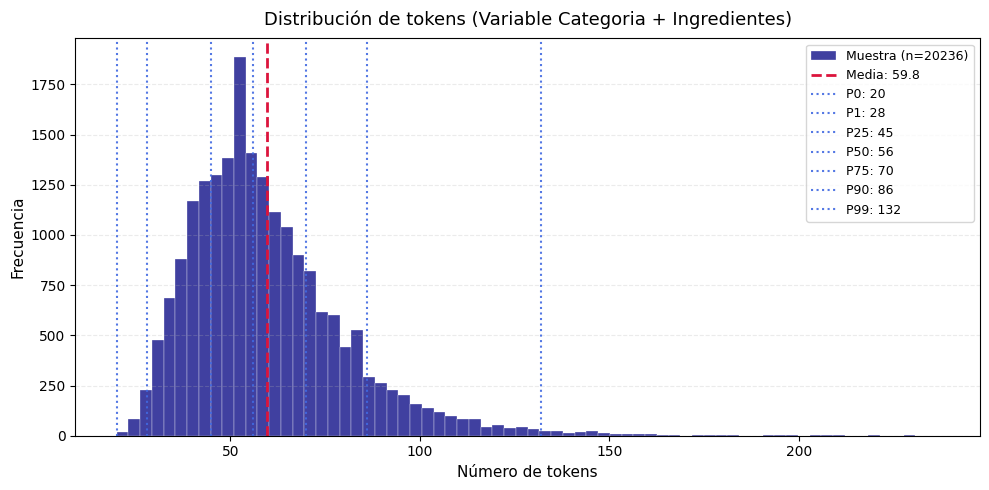

In [100]:
## Histograma de longitud de tokens


def count_tokens(text):
    return len(tokenizer(text, truncation=False)["input_ids"])


df_text = pd.DataFrame(formatted_dataset["train"])
sample_df = df_text.copy()
sample_df["token_len"] = sample_df["text"].apply(count_tokens)

percentiles = [0, 1, 25, 50, 75, 90, 99]
token_lengths = sample_df["token_len"]
pvals = [int(np.percentile(token_lengths, p)) for p in percentiles]
mean_len = token_lengths.mean()

plt.figure(figsize=(10, 5))
plt.hist(
    token_lengths,
    bins=70,
    color="navy",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3,
    label="Muestra (n={})".format(len(sample_df)),
)
plt.axvline(
    mean_len,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Media: {mean_len:.1f}",
)
for p, val in zip(percentiles, pvals):
    plt.axvline(
        val,
        color="royalblue",
        linestyle=":",
        linewidth=1.5,
        alpha=0.9,
        label=f"P{p}: {val}",
    )

plt.title(
    "Distribución de tokens (Variable Categoria + Ingredientes)", fontsize=13, pad=10
)
plt.xlabel("Número de tokens", fontsize=11)
plt.ylabel("Frecuencia", fontsize=11)
plt.grid(axis="y", alpha=0.25, linestyle="--")
plt.legend(frameon=True, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

**Análisis de longitud del texto y selección de `max_length`**

A partir del análisis de la longitud de los textos construidos (Categoría|Nombre + Ingredientes), se observa que:

- la mayoría de los ejemplos se concentran entre 45 y 85 tokens,
- la media se sitúa en torno a 60 tokens,
- el percentil 75 se encuentra aproximadamente entre 70 y 80 tokens,
- el percentil 90 alrededor de 86 tokens,
- y el percentil 99 alcanza aprox 132 tokens.

Dado este comportamiento, se selecciona un valor de:

**`max_length = 128`**

Esta decisión permite:

- capturar aprox el 99% de los ejemplos sin truncamiento significativo,
- reducir el consumo de memoria,
- aumentar la eficiencia del entrenamiento,
- y mejorar la estabilidad del modelo en el entorno de Google Colab.

Aunque algunos ejemplos más largos pueden ser truncados, estos corresponden a casos menos frecuentes, por lo que el impacto en el aprendizaje global es limitado.

Esta decisión representa una optimización clave, permitiendo aprovechar mejor el dataset disponible y mejorar el rendimiento del modelo.

## 4.2 Ejemplo de Wordclouds por categorias

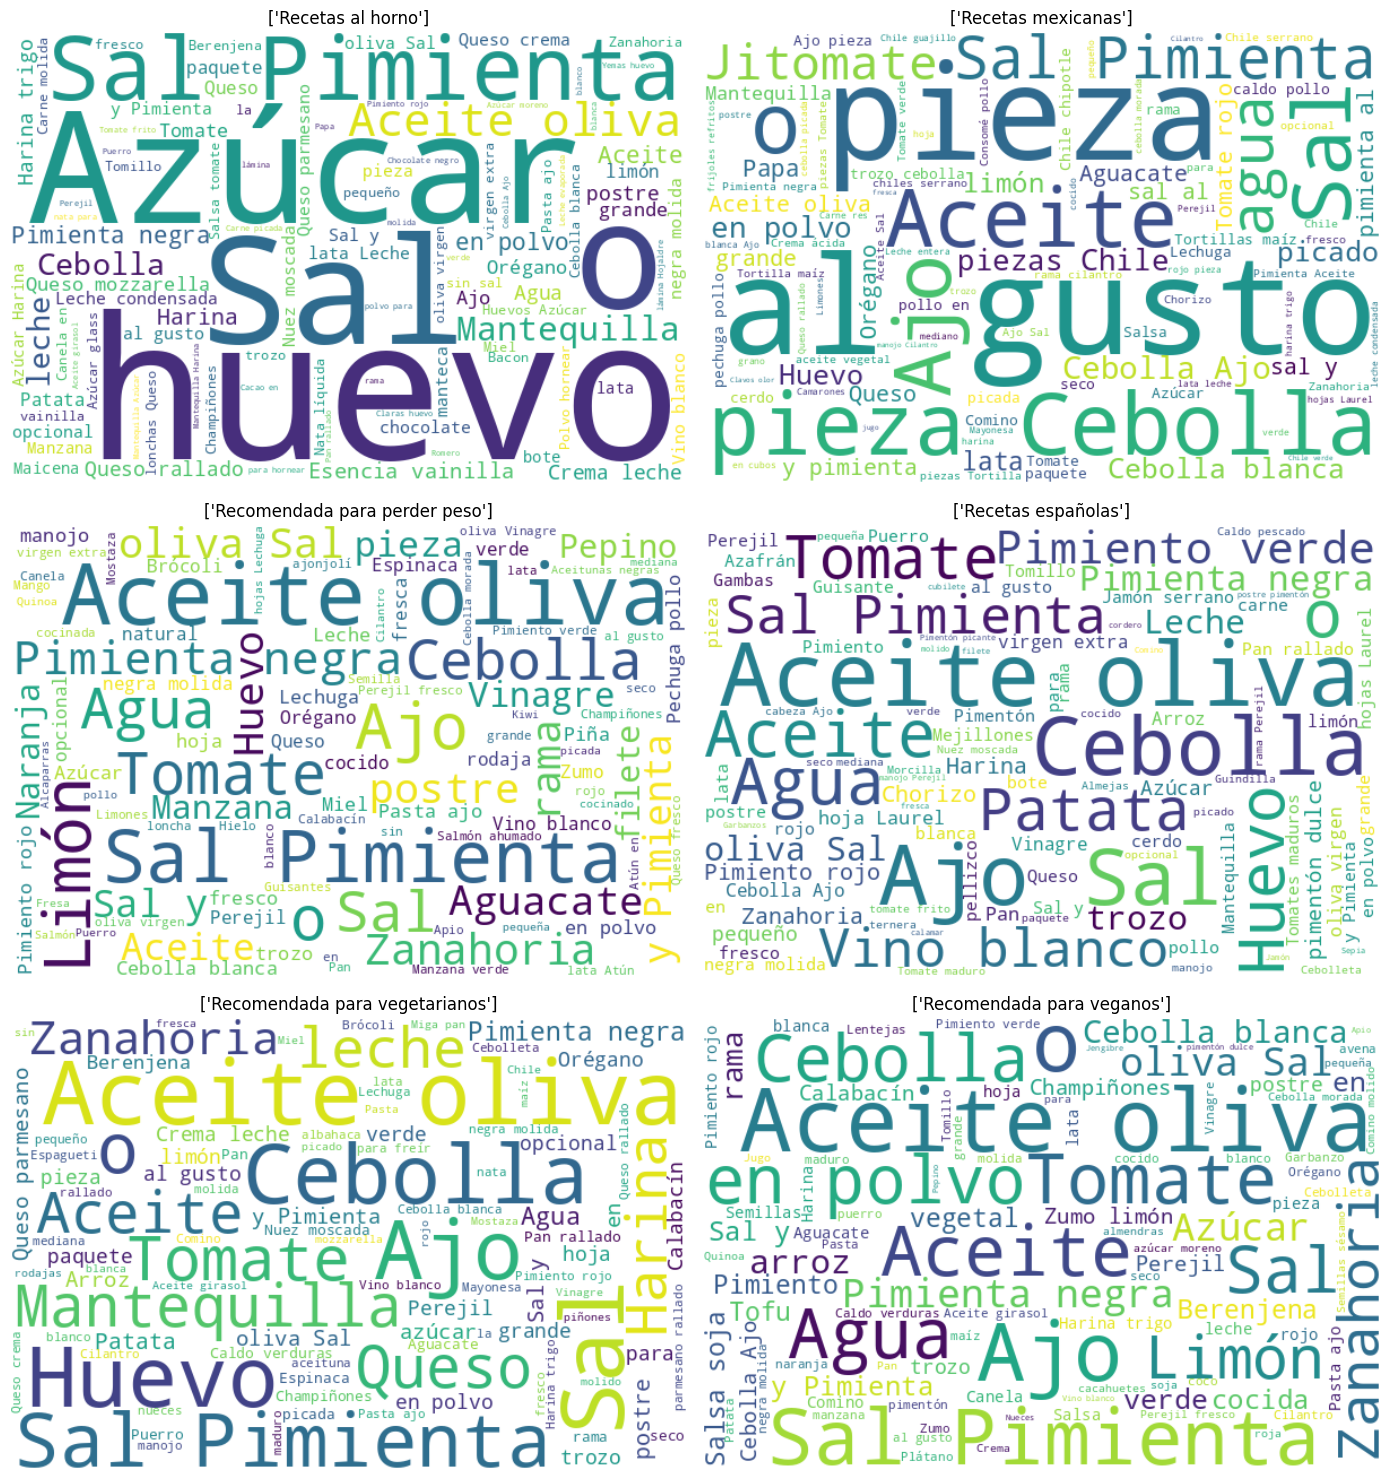

In [101]:
# Para top 6 categorias no nulas, graficar un wordcloud de los ingredientes más frecuentes
top_categorias = (
    df_text["Categoria"]
    .fillna("Desconocido")
    .str.strip()
    .replace("", "Desconocido")
    .value_counts()
    .head(8)
)

top_categorias.drop("Desconocido", errors="ignore", inplace=True)
top_categorias.drop("[]", errors="ignore", inplace=True)


# Crear figura con grilla 3x2
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for i, categoria in enumerate(top_categorias.index):
    subset = df_text[
        df_text["Categoria"]
        .fillna("Desconocido")
        .str.strip()
        .replace("", "Desconocido")
        == categoria
    ]

    text_corpus = " ".join(subset["Ingredientes"].apply(clean_text).tolist())

    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap="viridis",
        max_words=100,
    ).generate(text_corpus)

    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"{categoria}", fontsize=12)

plt.tight_layout()
plt.show()

**Notas:**

El análisis de las nubes de palabras permite identificar patrones claros en la distribución de ingredientes y su relación con cada tipo de receta. A nivel general, se observa una fuerte recurrencia de ingredientes base como ajo, cebolla, sal, aceite de oliva, tomate y pimienta, lo que sugiere la existencia de un núcleo común en la mayoría de las preparaciones.  

El dataset presenta una estructura coherente en la que coexisten ingredientes base comunes y elementos distintivos por categoría. Esto sugiere una adecuada separación semántica entre tipos de recetas, lo que resulta favorable para la tarea de generación de texto de este trabajo.

# **5. Preprocesamiento y Tokenización**

Una vez construido el texto unificado basado, se procede a la tokenización del corpus para su uso en el modelo GPT-2.

**Tokenización**

Dado que los modelos GPT-2 trabajan con secuencias de longitud fija, es necesario definir un parámetro `max_length`, que en este proyecto se estableció en:

**`max_length = 128`**

Este valor permite capturar la mayor parte de los ejemplos sin truncamiento significativo, manteniendo eficiencia computacional.

---

**Batch size y limitaciones computacionales**

En tareas de deep learning es común utilizar batch sizes grandes (por ejemplo, 64 o 128). Sin embargo, en modelos de lenguaje como GPT-2, el costo computacional es considerablemente mayor debido a:

- el número de parámetros del modelo,
- el procesamiento secuencial de tokens,
- y el almacenamiento de activaciones y gradientes durante el entrenamiento.

Por esta razón, se utilizan valores pequeños:

**`per_device_train_batch_size = 2 o 4`**

Estos valores son adecuados para el entorno de ejecución (GPU T4 en Google Colab) y permiten entrenar el modelo de forma estable.

---

**Batch size efectivo**

Para compensar el uso de batch sizes pequeños, se emplea la técnica de **gradient accumulation**, que permite simular un batch más grande.

Por ejemplo:

```python
per_device_train_batch_size = 4
gradient_accumulation_steps = 4
```
equivalente a un batch size efectivo de 4 x 4 = 16

Esto significa que el modelo acumula gradientes durante varios pasos antes de actualizar los pesos, logrando un efecto similar al de un batch más grande sin exceder las limitaciones de memoria.

## **5.1 Ajuste de Compatibilidad**

In [102]:
# Ajuste de compatibilidad entre tokenizer y modelo

# Si el tokenizer no tiene pad_token, usamos eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Redimensionar embeddings al tamaño real del tokenizer
model.resize_token_embeddings(len(tokenizer))

# Configuración explícita para entrenamiento
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.use_cache = False

print("tokenizer.vocab_size:", tokenizer.vocab_size)
print("len(tokenizer):", len(tokenizer))
print("pad_token_id:", tokenizer.pad_token_id)
print("eos_token_id:", tokenizer.eos_token_id)
print("embedding size:", model.get_input_embeddings().weight.shape[0])

tokenizer.vocab_size: 50265
len(tokenizer): 50266
pad_token_id: 50265
eos_token_id: 50265
embedding size: 50266


La salida obtenida confirma que el ajuste de compatibilidad fue exitoso: el tamaño de la matriz de embeddings del modelo coincide ahora con el tamaño efectivo del tokenizer (`len(tokenizer)`), garantizando que todos los tokens utilizados durante la tokenización tengan una representación válida dentro del modelo.

## **5.2 Tokenización**

In [103]:
# Tokenización

max_length = 128  # Basado en el percentil 99 de la longitud de tokens


def tokenize_function(examples):
    return tokenizer(
        examples["text"], truncation=True, padding="max_length", max_length=max_length
    )


tokenized_dataset = formatted_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=formatted_dataset["train"].column_names,
)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 20236
    })
})

## **5.3 Verificación de Compatibilidad**

In [104]:
# Verificación de rangos de tokens


sample_ids = tokenized_dataset["train"]["input_ids"][:1000]

max_id = max(max(x) for x in sample_ids)
min_id = min(min(x) for x in sample_ids)

print("Min token id:", min_id)
print("Max token id:", max_id)
print("Embedding size:", model.get_input_embeddings().weight.shape[0])

assert (
    max_id < model.get_input_embeddings().weight.shape[0]
), "Hay tokens fuera del rango de embeddings"
print("Verificación correcta: todos los tokens están dentro del rango válido.")

Min token id: 7
Max token id: 50265
Embedding size: 50266
Verificación correcta: todos los tokens están dentro del rango válido.


In [105]:
# Limpieza de columnas

tokenized_dataset = tokenized_dataset.remove_columns(
    [
        col
        for col in tokenized_dataset["train"].column_names
        if col != "input_ids" and col != "attention_mask"
    ]
)

## **5.4 Train / Validation Split**

In [106]:
# Train / Validation split

split_dataset = tokenized_dataset["train"].train_test_split(test_size=0.1, seed=42)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 18212
})
Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 2024
})


# **6. Generación con el modelo base**


Antes de realizar el fine-tuning, es importante evaluar cómo se comporta el modelo base frente a la nueva tarea planteada: generar ingredientes a partir de una categoría culinaria.

Esta evaluación cumple dos objetivos:

1. establecer una línea base cualitativa,
2. verificar si el modelo posee conocimiento previo suficiente sobre asociaciones entre tipos de recetas e ingredientes.

Se realizarán dos tipos de prueba:

- **prompts estructurados**, siguiendo el formato exacto del dataset de entrenamiento,
- **prompts naturales**, con formulaciones más abiertas y cercanas al lenguaje cotidiano.

Esto permitirá analizar no solo la calidad del modelo base, sino también su sensibilidad al formato del prompt.

## **6.1 Función de generación**

Se define una función de generación basada en `model.generate()`, la cual permite controlar distintos aspectos del muestreo, tales como:

- `max_new_tokens`: número máximo de tokens generados,
- `temperature`: nivel de aleatoriedad / creatividad,
- `top_k`: selección entre los tokens más probables,
- `top_p`: muestreo acumulado por probabilidad.

Además, se utiliza `no_repeat_ngram_size=3` para reducir repeticiones excesivas en la salida generada.

In [107]:
# Función de generación


def generate_text(
    prompt,
    model,
    tokenizer,
    max_new_tokens=120,
    min_new_tokens=10,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_new_tokens=min_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            no_repeat_ngram_size=3,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

## **6.2 Prompts de prueba**

En esta primera evaluación se utilizan prompts con la misma estructura que tendrá el corpus de entrenamiento:

```text
### Categoría:
postres

### Ingredientes:

In [108]:
# Prompts estructurados de prueba


prompts_structured = [
    "### Categoría:\npostres y horneados\n\n### Ingredientes:\n",
    "### Categoría:\nvegetarianos\n\n### Ingredientes:\n",
    "### Categoría:\nsopas y cremas\n\n### Ingredientes:\n",
    "### Categoría:\ncomida colombiana\n\n### Ingredientes:\n",
    "### Categoría:\ncomida mexicana\n\n### Ingredientes:\n",
]

for i, p in enumerate(prompts_structured, 1):
    print("=" * 100)
    print(f"PROMPT ESTRUCTURADO {i}")
    print(
        generate_text(
            p,
            model,
            tokenizer,
            max_new_tokens=100,
            temperature=0.7,
            top_k=50,
            top_p=0.95,
        )
    )
    print()

PROMPT ESTRUCTURADO 1
### Categoría:
postres y horneados

### Ingredientes:
(n) y xi (n)# Incluída: una libra de pan y un bol de queso.En la parte inferior del envase de los alimentos, hay una lista de ingredientes.Las etiquetas y los colores de las etiquetas de los productos envasados en envases de cartón pueden cambiar.En caso de que se presente la etiqueta de los postres, las etiquetas pueden modificarse.En el caso de los embalajes, los envases pueden cambiar a su color natural.No obstante, en la parte superior

PROMPT ESTRUCTURADO 2
### Categoría:
vegetarianos

### Ingredientes:
ves de comadres, de comuestes, de detat, de capítol, de propretat, de tot, de diu, de segures, de relés, de compes, de rebuix, de perquè, de carreres, de cas, de cues, per tipus de cas i de comptes, er article, er apartat 4.2.1, e er apart 6.1.2,

PROMPT ESTRUCTURADO 3
### Categoría:
sopas y cremas

### Ingredientes:
_encender.Ingredientes para: amp_enumerar.Incideciones: amp.IncontinuadoIncideción de la cr


***Se evidencian limitaciones importantes en su capacidad para generar contenido relevante dentro del dominio culinario:***

---

**Falta de adaptación al formato**

El modelo no logra interpretar correctamente la estructura semiestructurada propuesta. Esto se refleja en:

- generación de símbolos y caracteres irrelevantes,
- secuencias numéricas sin sentido,
- plantillas vacías o incompletas,
- y ausencia de listas coherentes de ingredientes.

Este comportamiento sugiere que el modelo base no ha sido expuesto durante su preentrenamiento a este tipo de formatos, por lo que no logra continuar la estructura de manera adecuada.

---

**Desviación fuera del dominio culinario**

En varios casos, el modelo genera contenido completamente ajeno al contexto de recetas, incluyendo:

- texto técnico o normativo,
- fragmentos con lenguaje legal o administrativo,
- estructuras propias de documentos formales.

Esto indica que el modelo está activando conocimiento general del lenguaje aprendido durante su preentrenamiento, pero no posee especialización en el dominio culinario.

---

**Ausencia de coherencia semántica**

No se observa correspondencia entre la categoría proporcionada y el contenido generado. Por ejemplo:

- para la categoría "postres" no aparecen ingredientes típicos como azúcar, harina o leche,
- para "sopas" se generan textos legales,
- y para "vegetarianos" se producen listas sin significado claro.

Esto evidencia que el modelo no está estableciendo relaciones semánticas entre la categoría y los ingredientes.

---

**Interpretación general**

En conjunto, estos resultados indican que el modelo base:

- no comprende el formato estructurado propuesto,
- no está alineado con la tarea de generación de ingredientes,
- y no logra capturar asociaciones entre categorías culinarias e ingredientes.

---

**Conclusión de la sección**

El desempeño del modelo base frente a prompts estructurados es claramente deficiente, lo cual es esperable dado que este tipo de formato no forma parte de su entrenamiento original.

Estos resultados establecen una línea base importante para el proyecto, evidenciando la necesidad de aplicar fine-tuning sobre un corpus específico que permita al modelo aprender tanto:

- la estructura del formato,
- como el dominio culinario.

Este análisis servirá como punto de comparación para evaluar posteriormente el impacto del modelo ajustado.

## **6.3 Prueba con Prompts mas naturales**

In [109]:
# Prompts naturales de prueba

prompts_naturales = [
    "Ingredientes típicos para un postre:\n",
    "Qué ingredientes lleva una receta vegetariana:\n",
    "Ingredientes comunes para una receta colombiana:\n",
    "Qué ingredientes se usan para cocinar pastas:\n",
    "Qué ingredientes se necesitan para cocinar tacos al pastor:\n",
]

for i, p in enumerate(prompts_naturales, 1):
    print("=" * 100)
    print(f"PROMPT NATURAL {i}")
    print(
        generate_text(
            p,
            model,
            tokenizer,
            max_new_tokens=100,
            temperature=0.8,
            top_k=50,
            top_p=0.95,
        )
    )
    print()

PROMPT NATURAL 1
Ingredientes típicos para un postre:
rusa de la pasta: el coloreado.Para una presentación de la materia en la mesa, la madera de la corteza del árbol debe ser plantada a medida que va creciendo, y luego ser cortado.En este caso la madera es cortada y colocada en un bloque de madera que se dobla sobre la parte superior de la mesa.La parte superior del bloque de la madera se coloca en un ángulo agudo de la parte inferior de la tabla de mesa.Esto es necesario para la fijación del punto de

PROMPT NATURAL 2
Qué ingredientes lleva una receta vegetariana:
n, lactobucal, chile en polvo, yuca, maíz, yol, y kraps.El queso se sirve tradicionalmente en recipientes abiertos.La carne es un alimento básico en muchas culturas, y el queso de cabra se sirve con la denominación "Queso de cabra" en la mayoría de las cocinas.El krap es un tipo de queso elaborado a base de queso de oveja o de cabra.Por lo general, el krapan es un queso de

PROMPT NATURAL 3
Ingredientes comunes para una rec

***Observaciones sobre prompts naturales (modelo base)***

Al evaluar el modelo base utilizando prompts más naturales, se observa un comportamiento diferente respecto a los prompts estructurados.

En este caso, los prompts utilizados fueron del tipo:

- "Ingredientes típicos para un postre"
- "Qué ingredientes lleva una receta vegetariana"
- "Ingredientes comunes para una sopa"
- "Qué ingredientes se usan para cocinar pollo"

---

**Mejora en fluidez del lenguaje**

A diferencia de los prompts estructurados, el modelo genera texto más fluido y gramaticalmente coherente. Se observa:

- uso de frases completas,
- continuidad narrativa,
- menor presencia de caracteres extraños o símbolos.

Esto sugiere que el modelo responde mejor a formatos de lenguaje natural, los cuales son más cercanos a su distribución de entrenamiento original.

---

**Presencia parcial de vocabulario culinario**

En algunos casos aparecen ingredientes o elementos relacionados con cocina, tales como:

- azúcar, vainilla, canela (postres),
- tomate, ajo, aceite de oliva (vegetarianos),
- pimienta, leche, huevos (pollo).

Esto indica que el modelo posee cierto conocimiento general del dominio culinario.

---

**Falta de estructura en la salida**

A pesar de la mejora en fluidez, el modelo no genera listas claras de ingredientes. En su lugar:

- mezcla ingredientes con instrucciones,
- introduce pasos de preparación innecesarios,
- no separa elementos de forma ordenada.

Esto limita la utilidad de la salida para la tarea específica de generación de ingredientes.

---

**Inconsistencias semánticas**

Se observan varios problemas de coherencia:

- inclusión de ingredientes incorrectos (ej. huevos en recetas vegetarianas),
- combinaciones poco realistas,
- repetición de ingredientes,
- y mezcla de contextos culinarios.

Además, en algunos casos el modelo deriva hacia texto técnico o económico (precios, regulaciones), lo cual evidencia falta de control temático.

---

**Comparación implícita con prompts estructurados**

En relación con la sección anterior:

- los prompts naturales producen texto más fluido,
- pero los prompts estructurados fallan más fuertemente en formato y coherencia.

Esto sugiere que el modelo base:

- entiende mejor el lenguaje natural,
- pero no está preparado para seguir estructuras específicas ni generar salidas controladas.

---

El modelo base presenta un desempeño moderadamente mejor con prompts naturales en términos de fluidez, pero sigue mostrando limitaciones importantes:

- no logra generar listas de ingredientes de forma estructurada,
- no mantiene coherencia completa con la categoría,
- y presenta errores semánticos frecuentes.

---

**Conclusión de la sección**

En conjunto, los resultados indican que el modelo base posee conocimiento general del lenguaje y cierto entendimiento del dominio culinario, pero no es capaz de resolver la tarea específica de generación de ingredientes de forma precisa.

Esto refuerza la necesidad de aplicar fine-tuning, con el fin de:

- enseñar al modelo el formato esperado,
- reforzar asociaciones entre categorías e ingredientes,
- y mejorar la coherencia de la generación.

# **7. Fine-tuning del modelo**

Una vez evaluado el modelo base, se procede al fine-tuning sobre el corpus completo construido a partir de las variables `Categoria` e `Ingredientes`.


## **7.1 Data Collator**

In [110]:
# Data collator para causal language modeling

from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

## **7.2 Training Arguments**

**Justificación de la configuración de entrenamiento**

La configuración de entrenamiento fue ajustada considerando tres factores:

1. **Longitud reducida de las secuencias**  
   Al trabajar con pocas variables y al aplicar un paso de limpieza o eliminación de caracterés. las entradas son mucho más cortas, lo que permite aumentar el batch size.

2. **Uso del dataset completo**  
   Resulta viable entrenar con todo el conjunto de datos disponible tras la partición train/validation.

3. **Estabilidad computacional**  
   Se emplea una configuración adaptada a una GPU T4 en Google Colab, utilizando batch sizes pequeños combinados con gradient accumulation para simular batches efectivos mayores. Adicionalmente, se emplea precisión mixta (fp16) para mejorar eficiencia y permitir mayores batch sizes

In [111]:
## Argumentos de entrenamiento optimizados


from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./gpt2-ingredientes-categoria",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,  # Para simular un batch size de 16
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,  # Para un calentamiento suave al inicio del entrenamiento
    fp16=True,  # Para acelerar el entrenamiento
    save_total_limit=3,
    load_best_model_at_end=True,
    report_to="none",
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## **7.3 Trainer**

In [112]:
# Inicialización del Trainer


from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

## **7.4 Entrenamiento**

In [113]:
# Entrenamiento

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.987466,1.974793
2,1.838712,1.879082
3,1.794098,1.853728


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=3417, training_loss=2.0577216283738493, metrics={'train_runtime': 1236.9396, 'train_samples_per_second': 44.17, 'train_steps_per_second': 2.762, 'total_flos': 3568987865088000.0, 'train_loss': 2.0577216283738493, 'epoch': 3.0})

**Resultados del entrenamiento**

El proceso de fine-tuning se completó de manera estable durante 3 épocas, sin presentar problemas numéricos ni errores de convergencia.

Los resultados obtenidos fueron los siguientes:

| Época | Training Loss | Validation Loss |
| ----- | ------------- | --------------- |
| 1     | 1.9875        | 1.9748          |
| 2     | 1.8387        | 1.8791          |
| 3     | 1.7941        | 1.8537          |


A partir de estos resultados se observan varios aspectos importantes:

- la pérdida de validación disminuye de forma consistente a lo largo de las épocas,
- la pérdida de entrenamiento y validación se mantienen cercanas entre sí,
- y no se evidencian señales fuertes de sobreajuste.

Esto sugiere que el modelo logró aprender asociaciones relevantes entre categorías culinarias e ingredientes, manteniendo una capacidad razonable de generalización sobre ejemplos no vistos.



# **8. Evaluación del modelo después del fine-tuning**

## **8.1 Métricas finales del entrenamiento**

Una vez finalizado el entrenamiento, se evalúa el comportamiento del modelo ajustado desde dos perspectivas:

1. **Cuantitativa**, mediante la revisión de la pérdida de entrenamiento, pérdida de validación y perplejidad.
2. **Cualitativa**, mediante la generación de recetas con los mismos prompts utilizados previamente para el modelo base.

Esta comparación permite analizar si el fine-tuning logró adaptar el modelo al dominio culinario y mejorar su capacidad para generar recetas más coherentes y estructuradas.

In [114]:
#  Historial de entrenamiento
history = pd.DataFrame(trainer.state.log_history)
history

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,4.928059,3.656168,8.684211e-06,0.087854,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.260799,2.465950,1.745614e-05,0.175708,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.572508,2.521609,2.622807e-05,0.263562,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.365488,2.016175,2.944390e-05,0.351417,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.242778,1.715601,2.846829e-05,0.439271,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2.127116,1.446217,2.749268e-05,0.527125,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2.097977,1.594382,2.651707e-05,0.614979,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2.053014,1.670405,2.554146e-05,0.702833,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2.043645,1.563141,2.456585e-05,0.790687,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2.018610,1.480842,2.359024e-05,0.878542,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
# Logs de entrenamiento y validación

train_logs = history[history["loss"].notna()].copy()
eval_logs = history[history["eval_loss"].notna()].copy()

print("Train logs:")
display(train_logs)

print("\nEval logs:")
display(eval_logs)

Train logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,4.928059,3.656168,8.684211e-06,0.087854,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.260799,2.465950,1.745614e-05,0.175708,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.572508,2.521609,2.622807e-05,0.263562,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.365488,2.016175,2.944390e-05,0.351417,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.242778,1.715601,2.846829e-05,0.439271,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2.127116,1.446217,2.749268e-05,0.527125,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2.097977,1.594382,2.651707e-05,0.614979,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2.053014,1.670405,2.554146e-05,0.702833,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2.043645,1.563141,2.456585e-05,0.790687,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2.018610,1.480842,2.359024e-05,0.878542,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Eval logs:


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
11,NaN,NaN,NaN,1.0,1139,1.974793,12.4158,163.018,40.755,NaN,NaN,NaN,NaN,NaN
23,NaN,NaN,NaN,2.0,2278,1.879082,12.3358,164.075,41.019,NaN,NaN,NaN,NaN,NaN
36,NaN,NaN,NaN,3.0,3417,1.853728,12.6117,160.485,40.121,NaN,NaN,NaN,NaN,NaN


In [116]:
# Evaluación final

eval_results = trainer.evaluate()
eval_results

{'eval_loss': 1.85372793674469,
 'eval_runtime': 12.913,
 'eval_samples_per_second': 156.741,
 'eval_steps_per_second': 39.185,
 'epoch': 3.0}

In [117]:
# Perplejidad

import math

perplexity = math.exp(eval_results["eval_loss"])
print("Eval loss:", eval_results["eval_loss"])
print("Perplexity:", perplexity)

Eval loss: 1.85372793674469
Perplexity: 6.383572775292237


### Evaluación del modelo ajustado

Tras el proceso de fine-tuning, se obtuvo:

- **Validation Loss:** 1.8537  
- **Perplexity:** 6.38  

---

#### Interpretación de la perplejidad

La perplejidad es una métrica utilizada en modelos de lenguaje para medir qué tan bien el modelo predice la siguiente palabra en una secuencia.

En términos simples, una perplejidad de 6.38 indica que, en promedio, el modelo considera alrededor de 6 posibles opciones para cada token. Esto refleja un nivel de incertidumbre moderado, pero aún dentro de un rango aceptable para tareas de generación de texto.

---

#### Análisis del resultado

Este valor de perplejidad sugiere que:

- el modelo ha logrado capturar patrones relevantes del dataset, aunque con menor precisión que en escenarios de ajuste más fino,
- existe una relación aprendida entre categorías e ingredientes, pero con mayor ambigüedad en la predicción,
- el modelo mantiene capacidad de generalización, aunque con margen de mejora en la calidad de las predicciones.

En conjunto, el desempeño puede considerarse **adecuado**, pero no óptimo, lo que abre la posibilidad de mejorar mediante ajuste de hiperparámetros (por ejemplo, learning rate, batch size efectivo o número de épocas).

---

#### Nota sobre la interpretación de métricas

*Loss (referencial):*

- < 2 → muy bueno  
- 2 – 3 → bueno  
- ~5 → bajo desempeño  

*Perplejidad (interpretación):*

| Perplexity | Interpretación |
| ---------- | -------------- |
| > 50       | muy mala       |
| 20–50      | mala           |
| 10–20      | regular        |
| 5–10       | buena          |
| **< 5**    | muy buena      |

## **8.2 Generación con el modelo fine-tuned**

Una vez completado el proceso de fine-tuning, se evalúa nuevamente el modelo utilizando los mismos prompts definidos previamente.

El objetivo es comparar el comportamiento del modelo antes y después del entrenamiento, analizando:

- coherencia de los ingredientes generados,
- alineación con la categoría proporcionada,
- estructura de la salida,
- y calidad general del texto.

Al igual que en la evaluación del modelo base, se utilizan dos tipos de prompts:

- prompts estructurados,
- prompts naturales.

Esto permite evaluar no solo la mejora en la tarea específica, sino también la capacidad de generalización del modelo.

In [118]:
# Prompts estructurados

prompts_structured = [
    "### Categoría:\npostres y horneados\n\n### Ingredientes:\n",
    "### Categoría:\nvegetarianos\n\n### Ingredientes:\n",
    "### Categoría:\nsopas y cremas\n\n### Ingredientes:\n",
    "### Categoría:\ncomida colombiana\n\n### Ingredientes:\n",
    "### Categoría:\ncomida mexicana\n\n### Ingredientes:\n",
]

for i, p in enumerate(prompts_structured, 1):
    print("=" * 100)
    print(f"PROMPT ESTRUCTURADO {i} (MODELO AJUSTADO)")
    print(
        generate_text(
            p, model, tokenizer, max_new_tokens=60, temperature=0.9, top_k=50, top_p=0.9
        )
    )
    print()

PROMPT ESTRUCTURADO 1 (MODELO AJUSTADO)
### Categoría:
postres y horneados

### Ingredientes:
lechuga grande, kilo huevo, leche, mantequilla, Sal, Aceite, postre Aceite oliva, postre Salsa tomate, postre Mostaza, postre Pimienta negra, postre Cúrcuma, postre Pimentón dulce, postre Polvo hornear, postre Pan rallado, postre

PROMPT ESTRUCTURADO 2 (MODELO AJUSTADO)
### Categoría:
vegetarianos

### Ingredientes:
filetes Apio, Pimiento morrón, Pechuga pavo, Leche coco, Sal, Pimienta negra, Aceite girasol, Aceitunas negras, Queso parmesano, Quesos pan molde, Salsa tomate, Cebolla blanca, Ajo, Vino blanco,

PROMPT ESTRUCTURADO 3 (MODELO AJUSTADO)
### Categoría:
sopas y cremas

### Ingredientes:
sal, lata cebolla pequeña, huevo, postre caldo pollo, postre comino, crema leche, agua, sal, pimienta, tomate, pan rallado, queso rallado opcional, leche evaporada, sal marina, mantequilla sin sal, aceite oliva, perejil, para decorar, pera,

PROMPT ESTRUCTURADO 4 (MODELO AJUSTADO)
### Categoría:
comida

### 8.2.1 Observaciones sobre prompts estructurados

Tras el fine-tuning, se observa una mejora significativa en el comportamiento del modelo frente a prompts estructurados.

---

#### a. Mejora en la estructura de salida

El modelo ahora es capaz de:

- continuar correctamente el formato del prompt,
- generar listas de ingredientes separadas por comas,
- y producir secuencias coherentes sin símbolos extraños ni ruido.

A diferencia del modelo base, desaparecen completamente los caracteres irrelevantes, estructuras numéricas sin sentido y fragmentos de texto técnico.

---

#### b. Coherencia con la categoría

Se evidencia una mejora importante en la relación entre la categoría y los ingredientes generados:

- **Postres y horneados**: aparecen ingredientes adecuados como *leche, huevos, azúcar, harina, canela*.
- **Sopas y cremas**: predominan ingredientes salados como *cebolla, tomate, ajo, aceite de oliva*.
- **Comida mexicana**: incluye elementos típicos como *queso, limón, cebolla, ajo, orégano*.
- **Comida colombiana**: aparecen *harina de maíz, queso, huevos*, coherentes con preparaciones tradicionales.

---

#### c. Limitaciones observadas

A pesar de la mejora, aún se presentan algunas inconsistencias:

- **ruido de codificación** (problemas de encoding en texto),
- **repetición de ingredientes** dentro de una misma generación,
- **combinaciones redundantes o poco naturales** (*almendra molida molida*, *azúcar moreno molida*),
- **mezcla de estilos o cocinas** en algunas categorías,
- y presencia de términos poco consistentes (*oración vegetal*).

Estas inconsistencias reflejan ruido en el dataset o en el preprocesamiento.
---

#### d. Interpretación

Estos resultados indican que el modelo ha aprendido:

- la estructura del formato,
- el estilo de listas de ingredientes,
- y parcialmente la relación semántica entre categorías e ingredientes.

Sin embargo, todavía presenta cierta dificultad para separar completamente los contextos culinarios entre categorías.

---

#### e. Conclusión


El fine-tuning permitió mejorar significativamente:

- la estructura de salida,
- la coherencia general,
- y la calidad sintáctica de las generaciones.

No obstante, persisten errores relacionados con:

- ruido en los datos,
- redundancias,
- y ambigüedad semántica entre categorías.

Esto sugiere que futuras mejoras deberían centrarse en:

- limpieza del dataset,
- normalización de texto,
- y posiblemente mayor ajuste de hiperparámetros o datos más específicos por categoría.

## **8.3 Prueba con prompts naturales**

In [119]:
# Prompts naturales - modelo ajustado


prompts_naturales = [
    "Ingredientes típicos para un postre:\n",
    "Qué ingredientes lleva una receta vegetariana:\n",
    "Ingredientes comunes para una receta colombiana:\n",
    "Qué ingredientes se usan para cocinar pastas:\n",
    "Qué ingredientes se necesitan para cocinar tacos al pastor:\n",
]

for i, p in enumerate(prompts_naturales, 1):
    print("=" * 100)
    print(f"PROMPT NATURAL {i} (MODELO AJUSTADO)")
    print(
        generate_text(
            p, model, tokenizer, max_new_tokens=50, temperature=1, top_k=50, top_p=0.9
        )
    )
    print()

PROMPT NATURAL 1 (MODELO AJUSTADO)
Ingredientes típicos para un postre:
apresas, huevo cocido, cch, pan tostado, czto harina, cp. aceite, sal, pimienta, rodajas perejil, cebolla, ajo, comino, agua tibia, aceite vegetal, oré

PROMPT NATURAL 2 (MODELO AJUSTADO)
Qué ingredientes lleva una receta vegetariana:
yogur griego, zumo yogur griego, huevos, queso feta, pan rallado, mantequilla para pasta, harina, leche, azúcar, sal, pimienta, huevo, levadura líquida, levadura vegetal, sal aromática, sal a gusto, azúcar en

PROMPT NATURAL 3 (MODELO AJUSTADO)
Ingredientes comunes para una receta colombiana:
naranjas en agua, tomates verdes, ajo, ajo picado, jugo naranja o limón, pimienta, sal al gusto, pimienta negra, comino al gusto para el palito, agua, pimienta al gusto al gusto por su sabor a pimienta negra

PROMPT NATURAL 4 (MODELO AJUSTADO)
Qué ingredientes se usan para cocinar pastas:
chocolate naranja, huevo o leche, azúcar glass, miel y menta, azúcar morena, leche entera, extracto vainilla,

### 8.3.1 Observaciones sobre prompts naturales (modelo ajustado)

En los prompts naturales, el modelo ajustado muestra mejoras respecto al modelo base, aunque con un comportamiento menos controlado que en los prompts estructurados.

---

#### 1. Mejora en coherencia parcial

El modelo es capaz de generar ingredientes reconocibles dentro del dominio culinario:

- aparecen elementos comunes como *cebolla, ajo, sal, pimienta, aceite*,
- en algunos casos hay asociaciones plausibles (ej. cocina colombiana con *tomate, cebolla, aguacate*),
- se mantiene el formato de lista separada por comas.

Sin embargo, la coherencia es solo parcial:

- en **postres** aparecen ingredientes no adecuados como *caviar o salsa holandesa*,
- en **vegetarianos** se incluyen elementos no válidos como *jamón*,
- en **tacos al pastor** faltan ingredientes clave y aparecen otros irrelevantes.


---

#### 2. Inconsistencias semánticas

Se observan problemas como:

- mezcla de categorías culinarias (ingredientes de alta cocina en postres),
- inclusión de ingredientes incompatibles con restricciones (ej. carne en vegetarianos),
- falta de especificidad cultural (tacos sin ingredientes característicos como achiote o piña).

Esto indica que el modelo:

- reconoce el dominio general,
- pero no logra mantener restricciones semánticas finas en prompts libres.

---

#### 3. Sensibilidad al formato

El modelo responde significativamente mejor cuando el prompt sigue el formato del dataset.

Esto confirma que:

El modelo ha aprendido fuertemente el patrón estructurado de entrenamiento.

---

#### Conclusión

El modelo ajustado mejora en prompts naturales en términos de dominio, pero su mejor desempeño se obtiene claramente en prompts estructurados.

Esto resalta la importancia del diseño del prompt en modelos generativos.

# **9. Comparación antes vs después**

**Comparación: modelo base vs modelo ajustado**

La comparación entre el modelo base y el modelo ajustado permite evidenciar claramente el impacto del fine-tuning.

---

**Modelo base**

- incapacidad para seguir el formato estructurado,
- generación de texto fuera de dominio (legal, técnico, incoherente),
- ausencia de listas de ingredientes,
- alta presencia de ruido.

---

**Modelo ajustado**

- generación estructurada de listas de ingredientes,
- alineación general con el dominio culinario,
- desaparición casi total de ruido y texto irrelevante,
- mayor coherencia en la salida.

---

**Diferencias clave observadas**

| Aspecto | Modelo Base | Modelo Ajustado |
|--------|-----------|----------------|
| Formato | No lo respeta | Sí lo respeta |
| Dominio culinario | Muy bajo | Medio Alto |
| Coherencia | Baja | Moderada–alta |
| Ruido | Alto | Bajo |
| Control de salida | Nulo | Bueno |




# **10. Conclusión**

El presente proyecto tuvo como objetivo evaluar la capacidad de un modelo generativo basado en GPT-2 para aprender patrones dentro de un dominio específico, mediante un proceso de fine-tuning sobre un corpus estructurado.

---

**Desempeño del modelo base**

El modelo base evidenció limitaciones importantes al enfrentarse a la tarea propuesta:

- incapacidad para seguir estructuras específicas de entrada,
- generación de texto fuera de dominio,
- baja coherencia semántica,
- y presencia significativa de ruido.

Si bien el modelo mostraba cierta capacidad de generación lingüística, no lograba producir resultados útiles en el contexto de recetas culinarias.

---
**Impacto del fine-tuning**

Tras el proceso de ajuste, el modelo mostró una mejora clara en múltiples dimensiones:

- capacidad para seguir el formato estructurado del dataset,
- generación de contenido dentro del dominio culinario,
- reducción significativa del ruido,
- y mayor coherencia en las secuencias generadas.

Estos resultados evidencian que el fine-tuning permite especializar un modelo generalista en tareas concretas de generación de texto.

---

**Evaluación cuantitativa**

El modelo ajustado alcanzó una perplejidad aproximada de: **6.38**

Este valor se considera dentro de un rango **bueno**, indicando que el modelo ha aprendido patrones relevantes del corpus, aunque con un nivel de incertidumbre moderado en la predicción de tokens.

La evolución de la pérdida de entrenamiento y validación muestra una disminución progresiva y estable, sin divergencias significativas, lo que sugiere una adecuada capacidad de generalización y ausencia de sobreajuste evidente en las épocas evaluadas.

---

**Sensibilidad al formato del prompt**

Uno de los hallazgos más relevantes del proyecto es la fuerte dependencia del modelo respecto al formato del prompt:

- el modelo responde mejor a estructuras similares a las vistas durante el entrenamiento,
- mientras que en prompts más naturales la generación es menos controlada.

Esto confirma la importancia del diseño del prompt en modelos generativos y su relación directa con el desempeño.

---

**Limitaciones del modelo**

A pesar de los resultados obtenidos, se identificaron varias limitaciones:

- inconsistencias semánticas en categorías específicas (ej. ingredientes no adecuados al contexto),
- mezcla de contextos culinarios entre diferentes tipos de recetas,
- repetición de ingredientes frecuentes del dataset,
- errores de codificación y normalización del texto,
- y menor precisión en escenarios de generación libre.

Estas limitaciones están asociadas tanto al tamaño del modelo como a la calidad y homogeneidad del dataset utilizado.

